# Crawling Link

*Nama : Mabrurah Eka Rahayu*

*NIM : 220411100150*

***Crawling Link***

#**1. Install dan Import Library**

In [3]:
!pip install builtwith

  Preparing metadata (setup.py) ... done
  Created wheel for builtwith: filename=builtwith-1.3.4-py3-none-any.whl size=36077 sha256=43d4b739fb61ac39492b6686c3387c03cfe243c3031ce61712779146940c8b5d
  Stored in directory: /root/.cache/pip/wheels/7f/2d/b2/606e3df914d4aeeab99c4a4e3e9a61673d2293c2e346db00c8
Successfully built builtwith


In [4]:
!pip install requests

In [5]:
!pip install beautifulsoup4

In [6]:
import builtwith
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
from IPython.display import display
from urllib.parse import urljoin, urlparse

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

#**2. Analisis**


In [8]:
res = builtwith.parse('https://www2.trunojoyo.ac.id/')
print(res)

{'web-servers': ['LiteSpeed'], 'font-scripts': ['Google Font API'], 'javascript-frameworks': ['Modernizr', 'jQuery', 'jQuery UI'], 'widgets': ['OWL Carousel'], 'photo-galleries': ['jQuery'], 'web-frameworks': ['Twitter Bootstrap'], 'ecommerce': ['WooCommerce'], 'cms': ['WordPress'], 'programming-languages': ['PHP'], 'blogs': ['PHP', 'WordPress']}


In [9]:
def crawling_website(link_awal, batas_halaman=50):
    sudah_dikunjungi = set()   # halaman yang sudah dikunjungi
    hasil = []                 # tempat menyimpan hasil crawling

    # ambil domain utama pakai netloc
    domain_utama = urlparse(link_awal).netloc.replace("www.", "")
    antrian = [link_awal]      # halaman awal untuk dimasukkan ke antrian

    nomor_id = 1

    while antrian and len(sudah_dikunjungi) < batas_halaman:
        link_sekarang = antrian.pop(0)

        if link_sekarang in sudah_dikunjungi:
            continue
        sudah_dikunjungi.add(link_sekarang)

        try:
            respon = requests.get(link_sekarang, timeout=10)
            respon.raise_for_status()
            halaman = BeautifulSoup(respon.content, "html.parser")

            # cari semua link di halaman
            semua_link = halaman.find_all("a", href=True)
            for tag_link in semua_link:
                href = tag_link["href"]
                link_lengkap = urljoin(link_sekarang, href)  # ubah jadi absolute URL
                link_terurai = urlparse(link_lengkap)

                # cek apakah domain sama persis dengan domain utama (bukan subdomain)
                if link_terurai.scheme in ["http", "https"]:
                    domain_link = link_terurai.netloc.replace("www.", "")
                    if domain_link == domain_utama:
                        # simpan ke hasil
                        hasil.append({
                            "id": nomor_id,
                            "page": link_sekarang,
                            "link_keluar": link_lengkap
                        })
                        nomor_id += 1

                        # masukkan ke antrian kalau belum pernah dikunjungi
                        if link_lengkap not in sudah_dikunjungi and link_lengkap not in antrian:
                            antrian.append(link_lengkap)

        except requests.exceptions.RequestException:
            # Lewati halaman yang error tanpa warning
            continue

    # simpan hasil ke CSV
    data_tabel = pd.DataFrame(hasil)
    data_tabel.to_csv("PPWCrawlingLink.csv", index=False, encoding="utf-8-sig")
    return data_tabel

In [10]:
tabel_hasil = crawling_website("https://www2.trunojoyo.ac.id/", batas_halaman=50)
display(tabel_hasil.head(10))

,id,page,link_keluar
0,1,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
1,2,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
2,3,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
3,4,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
4,5,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
5,6,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
6,7,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/sejarah...
7,8,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/profil-...
8,9,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/visimisi/
9,10,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/lhm/


In [14]:
def Graph_Crawling(data_tabel):
    """Bangun graf berarah dari DataFrame hasil crawling"""
    G = nx.DiGraph()
    for _, baris in data_tabel.iterrows():
        halaman = baris["page"]
        link_keluar = baris["link_keluar"]

        if halaman not in G:
            G.add_node(halaman, tipe="page")
        if link_keluar not in G:
            G.add_node(link_keluar, tipe="link")

        G.add_edge(halaman, link_keluar)
    return G

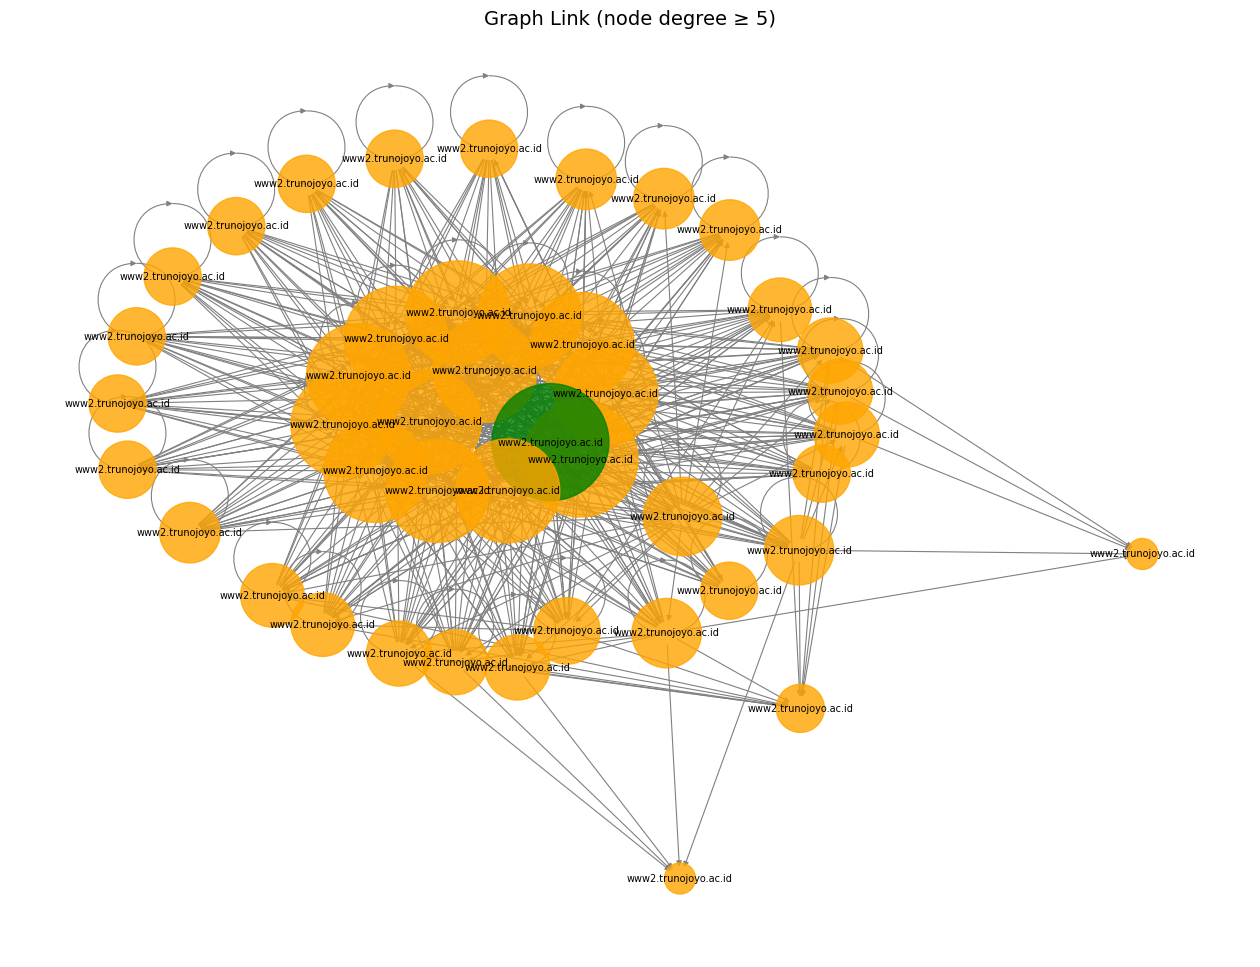

In [15]:
def plot_graph(graf, min_degree=5):
    """Gambar graf dengan styling lebih rapi"""
    # filter node dengan degree minimal tertentu biar tidak terlalu padat
    sub_nodes = [n for n in graf.nodes() if graf.degree(n) >= min_degree]
    sub_graf = graf.subgraph(sub_nodes)

    plt.figure(figsize=(16, 12))

    pos = nx.kamada_kawai_layout(sub_graf)  # layout lebih rapi

    # ukuran node sesuai degree
    sizes = [sub_graf.degree(n) * 100 for n in sub_graf.nodes()]
    # warna node sesuai tipe
    colors = ["green" if sub_graf.nodes[n]["tipe"] == "page" else "orange" for n in sub_graf.nodes()]

    nx.draw_networkx_nodes(sub_graf, pos, node_size=sizes, node_color=colors, alpha=0.8)
    nx.draw_networkx_edges(sub_graf, pos, edge_color="gray", arrowsize=8, width=0.8)

    # label pendek: ambil domain saja kalau URL panjang
    labels = {}
    for n in sub_graf.nodes():
        parsed = urlparse(n)
        if parsed.netloc:  # kalau ini URL
            labels[n] = parsed.netloc
        else:
            labels[n] = n[:30]  # potong nama panjang

    nx.draw_networkx_labels(sub_graf, pos, labels=labels, font_size=7)

    plt.title(f"Graph Link (node degree ≥ {min_degree})", fontsize=14)
    plt.axis("off")
    plt.show()

# ---- contoh pemakaian ----
graf = Graph_Crawling(tabel_hasil)
plot_graph(graf, min_degree=5)